# 09 — Hybrid CNN-QNN
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Implement and evaluate a Hybrid Classical-Quantum Neural Network combining a classical
fully-connected front-end with a Parameterized Quantum Circuit (PQC) backend.

## Architecture
```
26 hand-crafted physiological features
  -> Linear(64) + ReLU + Dropout(0.3)
  -> Linear(16) + ReLU
  -> Linear(n_qubits)          # bottleneck to match qubit count
  -> MinMaxScaler(-pi, pi)     # angle encoding
  -> Parameterized Quantum Circuit (PQC)
  -> Measurement
  -> Linear(n_classes)         # classical output head
```

## Why Hand-Crafted Features (not raw signals)?
The standalone 1D-CNN on raw signals failed under LOSO (F1=0.39) due to insufficient
data for convolutional filter learning. Hand-crafted features provide a stable,
physiologically meaningful input representation that allows the classical front-end
to learn a compact encoding for the quantum layer.

## Optimizer
Adam optimizer via PyTorch autograd — trains classical and quantum layers end-to-end.
Parameter-shift rule computes quantum gradients analytically via PennyLane TorchLayer.

## Data Conditions
- Full dataset (no subsampling) — deep learning needs more data than quantum kernels
- RobustScaler + MinMaxScaler(-pi, pi) preprocessing
- LOSO cross-validation

---


## 0. Configuration & Imports

In [17]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '09_hybrid_cnn_qnn')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

ECG_FEATURE_PREFIXES = ['ecg_']
RANDOM_STATE         = 42
DEVICE               = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hybrid model config ───────────────────────────────────────────────────────
N_QUBITS    = 4      # quantum layer width
N_LAYERS    = 2      # PQC depth (number of variational layers)
EPOCHS      = 40
BATCH_SIZE  = 32
LR          = 1e-3

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Device    : {DEVICE}')
print(f'  N qubits  : {N_QUBITS}')
print(f'  PQC layers: {N_LAYERS}')
print(f'  Epochs    : {EPOCHS}')
print(f'  LR        : {LR}')


Configuration ready.
  Device    : cpu
  N qubits  : 4
  PQC layers: 2
  Epochs    : 40
  LR        : 0.001


## 1. Load Datasets

In [12]:
df_wesad_bin = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv'))
df_wesad_3cl = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_3class.csv'))
wesad_feat_cols = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')))

df_dreamer = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'))
dreamer_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')))
dreamer_eeg_feats = [c for c in dreamer_all_feats
                     if not any(c.startswith(p) for p in ECG_FEATURE_PREFIXES)]

# Remove all-NaN columns from feature lists
all_nan_wesad = ['resp_mean_rate', 'resp_std_rate', 
                 'resp_mean_amp', 'resp_std_amp']
wesad_feat_cols = [c for c in wesad_feat_cols 
                   if c not in all_nan_wesad]

all_nan_dreamer = [c for c in dreamer_eeg_feats 
                   if df_dreamer[c].isna().all()]
dreamer_eeg_feats = [c for c in dreamer_eeg_feats 
                     if c not in all_nan_dreamer]

print(f'WESAD features after cleanup  : {len(wesad_feat_cols)}')
print(f'DREAMER features after cleanup: {len(dreamer_eeg_feats)}')

print('=== Datasets Loaded ===')
print(f'WESAD binary   : {df_wesad_bin.shape}  features={len(wesad_feat_cols)}')
print(f'WESAD 3-class  : {df_wesad_3cl.shape}')
print(f'DREAMER binary : {df_dreamer.shape}  EEG features={len(dreamer_eeg_feats)}')


WESAD features after cleanup  : 22
DREAMER features after cleanup: 134
=== Datasets Loaded ===
WESAD binary   : (883, 30)  features=22
WESAD 3-class  : (1049, 30)
DREAMER binary : (414, 146)  EEG features=134


## 2. PennyLane Quantum Circuit

Quantum circuit defined.
  Qubits            : 4
  Variational layers: 2
  Trainable params  : 8
  Embedding         : AngleEmbedding (Y rotation)
  Ansatz            : BasicEntanglerLayers
  Diff method       : parameter-shift (batched)

Circuit diagram:
0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤  <Z>
3: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─┤  <Z>

M0 = 
[0. 0. 0. 0.]
M1 = 
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]


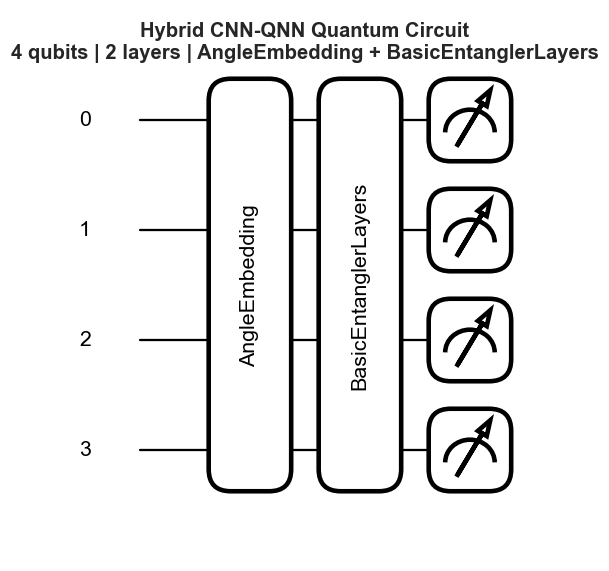

Saved: ..\results\plots\09_hybrid_cnn_qnn\hybrid_quantum_circuit.png


In [24]:
# PennyLane device — default.qubit statevector simulator
dev = qml.device('default.qubit', wires=N_QUBITS)


@qml.qnode(dev, interface='torch', diff_method='backprop')
def quantum_circuit(inputs, weights):
    """
    Parameterized quantum circuit with batched processing.
    inputs  : (N_QUBITS,) or (batch, N_QUBITS) — angle-encoded data
    weights : (N_LAYERS, N_QUBITS) — trainable rotation angles
    Returns : expectation values of PauliZ on each qubit
    """
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


# Wrap as TorchLayer — supports batched forward pass
weight_shapes = {'weights': (N_LAYERS, N_QUBITS)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

print('Quantum circuit defined.')
print(f'  Qubits            : {N_QUBITS}')
print(f'  Variational layers: {N_LAYERS}')
print(f'  Trainable params  : {N_LAYERS * N_QUBITS}')
print(f'  Embedding         : AngleEmbedding (Y rotation)')
print(f'  Ansatz            : BasicEntanglerLayers')
print(f'  Diff method       : parameter-shift (batched)')

# Draw circuit
print('\nCircuit diagram:')
inputs_ex  = pnp.zeros(N_QUBITS)
weights_ex = pnp.zeros((N_LAYERS, N_QUBITS))
print(qml.draw(quantum_circuit)(inputs_ex, weights_ex))

# Save circuit diagram
fig, ax = qml.draw_mpl(quantum_circuit, expansion_strategy='device')(inputs_ex, weights_ex)
fig.suptitle(f'Hybrid CNN-QNN Quantum Circuit\n'
             f'{N_QUBITS} qubits | {N_LAYERS} layers | '
             f'AngleEmbedding + BasicEntanglerLayers',
             fontweight='bold')
p = os.path.join(PLOTS_DIR, 'hybrid_quantum_circuit.png')
fig.savefig(p, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {p}')

## 3. Hybrid CNN-QNN Architecture

In [25]:
class HybridCNNQNN(nn.Module):
    """
    Hybrid Classical-Quantum Neural Network.

    Classical front-end: fully-connected layers compress
    physiological features to N_QUBITS dimensions.

    Quantum layer: PennyLane PQC processes the compressed
    representation in Hilbert space.

    Classical output head: maps quantum measurements to
    class probabilities.
    """
    def __init__(self, n_features, n_qubits, n_classes, dropout=0.3):
        super().__init__()
        self.n_qubits  = n_qubits
        self.n_classes = n_classes

        # Classical front-end
        self.classical_front = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, n_qubits),
            nn.Tanh()   # bound output to (-1, 1) before angle scaling
        )

        # Angle scaling: map (-1,1) to (-pi, pi)
        self.angle_scale = np.pi

        # Quantum layer
        self.quantum_layer = quantum_layer

        # Classical output head
        self.classical_out = nn.Linear(n_qubits, n_classes)

    def forward(self, x):
        # Classical compression
        x = self.classical_front(x)      # (batch, n_qubits)
        x = x * self.angle_scale         # scale to (-pi, pi)
        
        # Quantum layer — batched processing
        quantum_out = self.quantum_layer(x)  # (batch, n_qubits)
        
        # Classical output
        return self.classical_out(quantum_out)


# Architecture test
_model = HybridCNNQNN(n_features=26, n_qubits=N_QUBITS, n_classes=2)
_x     = torch.randn(4, 26)
_out   = _model(_x)
print(f'Architecture test: input={list(_x.shape)} -> output={list(_out.shape)}')
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params}')
classical_params = sum(p.numel() for p in _model.classical_front.parameters()) + \
                   sum(p.numel() for p in _model.classical_out.parameters())
quantum_params   = total_params - classical_params
print(f'  Classical params : {classical_params}')
print(f'  Quantum params   : {quantum_params}')
del _model, _x, _out


Architecture test: input=[4, 26] -> output=[4, 2]
Total trainable parameters: 2854
  Classical params : 2846
  Quantum params   : 8


## 4. Training Utilities

In [26]:
def get_weighted_sampler(y):
    counts  = np.bincount(y)
    weights = 1.0 / counts[y]
    return WeightedRandomSampler(
        torch.tensor(weights, dtype=torch.float32),
        num_samples=len(weights), replacement=True)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def eval_model(model, loader, criterion):
    model.eval()
    all_preds, all_true = [], []
    total_loss, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            out   = model(X_batch)
            loss  = criterion(out, y_batch)
            total_loss += loss.item() * len(y_batch)
            total      += len(y_batch)
            all_preds.extend(out.argmax(1).numpy().tolist())
            all_true.extend(y_batch.numpy().tolist())
    return total_loss/total, all_preds, all_true


def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred,
                           average=average, zero_division=0)),
    }


print('Training utilities defined.')


Training utilities defined.


## 5. LOSO Pipeline

In [27]:
def run_hybrid_loso(df, feature_cols, label_col, subject_col,
                    task_name, average='macro'):
    """
    LOSO cross-validation for the Hybrid CNN-QNN.
    Uses full dataset (no subsampling) — deep learning needs more data.
    """
    subjects  = sorted(df[subject_col].unique())
    classes   = sorted(df[label_col].unique())
    n_cls     = len(classes)
    n_feats   = len(feature_cols)

    fold_rows  = []
    cm_accum   = np.zeros((n_cls, n_cls), dtype=int)
    train_curves = []

    print(f'\n=== {task_name} — Hybrid LOSO ({len(subjects)} folds) ===')
    print(f'    Epochs={EPOCHS}  BS={BATCH_SIZE}  LR={LR}  Qubits={N_QUBITS}')

    for fold_i, test_sid in enumerate(subjects):
        train_mask = df[subject_col] != test_sid
        test_mask  = df[subject_col] == test_sid

        X_train = df.loc[train_mask, feature_cols].values.astype(float)
        y_train = df.loc[train_mask, label_col].values.astype(int)
        X_test  = df.loc[test_mask,  feature_cols].values.astype(float)
        y_test  = df.loc[test_mask,  label_col].values.astype(int)

        # Impute
        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)

        # RobustScaler
        scaler  = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        # Convert to tensors
        X_tr_t = torch.tensor(X_train, dtype=torch.float32)
        y_tr_t = torch.tensor(y_train, dtype=torch.long)
        X_te_t = torch.tensor(X_test,  dtype=torch.float32)
        y_te_t = torch.tensor(y_test,  dtype=torch.long)

        # Weighted sampler for class imbalance
        sampler      = get_weighted_sampler(y_train)
        train_ds     = TensorDataset(X_tr_t, y_tr_t)
        test_ds      = TensorDataset(X_te_t, y_te_t)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                                  sampler=sampler)
        test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                                  shuffle=False)

        # Fresh model each fold
        model     = HybridCNNQNN(n_features=n_feats,
                                  n_qubits=N_QUBITS,
                                  n_classes=n_cls)
        optimizer = optim.Adam(model.parameters(), lr=LR,
                               weight_decay=1e-4)
        scheduler = optim.lr_scheduler.StepLR(
                               optimizer, step_size=15, gamma=0.5)
        criterion = nn.CrossEntropyLoss()

        # Train
        t0 = time.time()
        for epoch in range(EPOCHS):
            tr_loss, tr_acc = train_epoch(
                model, train_loader, optimizer, criterion)
            scheduler.step()
            train_curves.append({
                'fold': fold_i+1, 'epoch': epoch+1,
                'train_loss': tr_loss, 'train_acc': tr_acc
            })
        train_time = time.time() - t0

        # Evaluate
        t1 = time.time()
        _, y_pred, y_true = eval_model(model, test_loader, criterion)
        test_time = time.time() - t1

        metrics = compute_metrics(y_true, y_pred, average=average)
        cm      = confusion_matrix(y_true, y_pred, labels=classes)
        cm_accum += cm

        fold_rows.append({
            'task'        : task_name,
            'model'       : 'Hybrid CNN-QNN',
            'fold'        : fold_i + 1,
            'test_subject': int(test_sid),
            'train_size'  : len(y_train),
            'test_size'   : len(y_test),
            'train_time'  : round(train_time, 2),
            'test_time'   : round(test_time, 4),
            **metrics
        })

        print(f'  Fold {fold_i+1:2d}/{len(subjects)} '
              f'test=S{test_sid:2d}  '
              f'acc={metrics["accuracy"]:.3f}  '
              f'f1={metrics["f1"]:.3f}  '
              f'train={train_time:.0f}s')

        del model

    return (pd.DataFrame(fold_rows),
            cm_accum,
            pd.DataFrame(train_curves))


print('Hybrid LOSO pipeline defined.')


Hybrid LOSO pipeline defined.


## 6. WESAD Binary Task
> Expect 20-40 minutes.

In [28]:
results_wb, cm_wb, curves_wb = run_hybrid_loso(
    df           = df_wesad_bin,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_binary_Hybrid',
)
print('\n=== WESAD Binary Hybrid — Mean Metrics ===')
print(results_wb[['accuracy','precision','recall','f1',
                   'train_time']].mean().round(4).to_string())
print(f'Std F1: {results_wb["f1"].std():.4f}')



=== WESAD_binary_Hybrid — Hybrid LOSO (15 folds) ===
    Epochs=40  BS=32  LR=0.001  Qubits=4
  Fold  1/15 test=S 2  acc=0.607  f1=0.378  train=16s
  Fold  2/15 test=S 3  acc=0.807  f1=0.746  train=15s
  Fold  3/15 test=S 4  acc=1.000  f1=1.000  train=15s
  Fold  4/15 test=S 5  acc=0.983  f1=0.981  train=15s
  Fold  5/15 test=S 6  acc=1.000  f1=1.000  train=16s
  Fold  6/15 test=S 7  acc=0.847  f1=0.843  train=16s
  Fold  7/15 test=S 8  acc=0.932  f1=0.922  train=16s
  Fold  8/15 test=S 9  acc=0.879  f1=0.857  train=16s
  Fold  9/15 test=S10  acc=0.900  f1=0.897  train=16s
  Fold 10/15 test=S11  acc=0.983  f1=0.982  train=16s
  Fold 11/15 test=S13  acc=0.864  f1=0.852  train=16s
  Fold 12/15 test=S14  acc=1.000  f1=1.000  train=16s
  Fold 13/15 test=S15  acc=0.733  f1=0.644  train=16s
  Fold 14/15 test=S16  acc=1.000  f1=1.000  train=16s
  Fold 15/15 test=S17  acc=1.000  f1=1.000  train=16s

=== WESAD Binary Hybrid — Mean Metrics ===
accuracy       0.9025
precision      0.8928
recall 

## 7. WESAD 3-Class Task

In [29]:
results_w3, cm_w3, curves_w3 = run_hybrid_loso(
    df           = df_wesad_3cl,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_3class_Hybrid',
    average      = 'macro',
)
print('\n=== WESAD 3-Class Hybrid — Mean Metrics ===')
print(results_w3[['accuracy','precision','recall','f1',
                   'train_time']].mean().round(4).to_string())
print(f'Std F1: {results_w3["f1"].std():.4f}')



=== WESAD_3class_Hybrid — Hybrid LOSO (15 folds) ===
    Epochs=40  BS=32  LR=0.001  Qubits=4
  Fold  1/15 test=S 2  acc=0.478  f1=0.215  train=18s
  Fold  2/15 test=S 3  acc=0.706  f1=0.679  train=18s
  Fold  3/15 test=S 4  acc=0.868  f1=0.733  train=19s
  Fold  4/15 test=S 5  acc=0.714  f1=0.670  train=18s
  Fold  5/15 test=S 6  acc=0.886  f1=0.778  train=19s
  Fold  6/15 test=S 7  acc=0.686  f1=0.702  train=19s
  Fold  7/15 test=S 8  acc=0.757  f1=0.638  train=19s
  Fold  8/15 test=S 9  acc=0.486  f1=0.291  train=20s
  Fold  9/15 test=S10  acc=0.408  f1=0.397  train=20s
  Fold 10/15 test=S11  acc=0.600  f1=0.576  train=20s
  Fold 11/15 test=S13  acc=0.629  f1=0.462  train=20s
  Fold 12/15 test=S14  acc=0.429  f1=0.456  train=20s
  Fold 13/15 test=S15  acc=0.718  f1=0.632  train=20s
  Fold 14/15 test=S16  acc=0.458  f1=0.470  train=20s
  Fold 15/15 test=S17  acc=0.931  f1=0.875  train=20s

=== WESAD 3-Class Hybrid — Mean Metrics ===
accuracy       0.6502
precision      0.6283
recall

## 8. DREAMER Binary EEG Task

In [30]:
results_db, cm_db, curves_db = run_hybrid_loso(
    df           = df_dreamer,
    feature_cols = dreamer_eeg_feats,
    label_col    = 'arousal_binary',
    subject_col  = 'subject_id',
    task_name    = 'DREAMER_binary_EEG_Hybrid',
    average      = 'macro',
)
print('\n=== DREAMER Binary EEG Hybrid — Mean Metrics ===')
print(results_db[['accuracy','precision','recall','f1',
                   'train_time']].mean().round(4).to_string())
print(f'Std F1: {results_db["f1"].std():.4f}')



=== DREAMER_binary_EEG_Hybrid — Hybrid LOSO (23 folds) ===
    Epochs=40  BS=32  LR=0.001  Qubits=4
  Fold  1/23 test=S 1  acc=0.556  f1=0.357  train=10s
  Fold  2/23 test=S 2  acc=0.444  f1=0.416  train=8s
  Fold  3/23 test=S 3  acc=0.556  f1=0.550  train=8s
  Fold  4/23 test=S 4  acc=0.444  f1=0.444  train=8s
  Fold  5/23 test=S 5  acc=0.500  f1=0.486  train=8s
  Fold  6/23 test=S 6  acc=0.500  f1=0.486  train=8s
  Fold  7/23 test=S 7  acc=0.611  f1=0.481  train=8s
  Fold  8/23 test=S 8  acc=0.556  f1=0.532  train=8s
  Fold  9/23 test=S 9  acc=0.278  f1=0.276  train=8s
  Fold 10/23 test=S10  acc=0.444  f1=0.416  train=8s
  Fold 11/23 test=S11  acc=0.500  f1=0.458  train=8s
  Fold 12/23 test=S12  acc=0.222  f1=0.212  train=8s
  Fold 13/23 test=S13  acc=0.389  f1=0.387  train=8s
  Fold 14/23 test=S14  acc=0.444  f1=0.444  train=8s
  Fold 15/23 test=S15  acc=0.389  f1=0.387  train=8s
  Fold 16/23 test=S16  acc=0.722  f1=0.714  train=8s
  Fold 17/23 test=S17  acc=0.611  f1=0.542  train=

## 9. Results & Plots

In [31]:
all_hybrid = pd.concat([results_wb, results_w3, results_db],
                        ignore_index=True)

summary_hybrid = (
    all_hybrid.groupby('task')
    .agg(
        accuracy_mean  = ('accuracy',  'mean'),
        accuracy_std   = ('accuracy',  'std'),
        precision_mean = ('precision', 'mean'),
        recall_mean    = ('recall',    'mean'),
        f1_mean        = ('f1',        'mean'),
        f1_std         = ('f1',        'std'),
        train_time_mean= ('train_time','mean'),
    )
    .round(4).reset_index()
)
summary_hybrid['model'] = 'Hybrid CNN-QNN'

print('=== HYBRID CNN-QNN SUMMARY ===')
print(summary_hybrid.to_string(index=False))

p = os.path.join(OUTPUT_DATA_DIR, 'hybrid_cnn_qnn_summary.csv')
summary_hybrid.to_csv(p, index=False)
print(f'\nSaved: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'hybrid_cnn_qnn_per_fold.csv')
all_hybrid.to_csv(p2, index=False)
print(f'Saved: {p2}')


=== HYBRID CNN-QNN SUMMARY ===
                     task  accuracy_mean  accuracy_std  precision_mean  recall_mean  f1_mean  f1_std  train_time_mean          model
DREAMER_binary_EEG_Hybrid         0.4662        0.1305          0.4546       0.4658   0.4258  0.1211           8.1813 Hybrid CNN-QNN
      WESAD_3class_Hybrid         0.6502        0.1712          0.6283       0.6294   0.5716  0.1850          19.3253 Hybrid CNN-QNN
      WESAD_binary_Hybrid         0.9025        0.1169          0.8928       0.8803   0.8735  0.1737          15.7887 Hybrid CNN-QNN

Saved: ..\results\output_data\hybrid_cnn_qnn_summary.csv
Saved: ..\results\output_data\hybrid_cnn_qnn_per_fold.csv


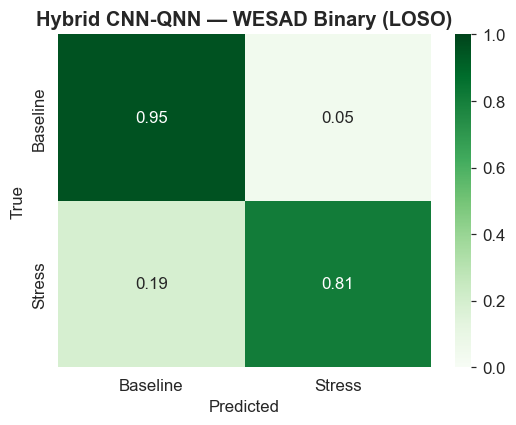

Saved: ..\results\plots\09_hybrid_cnn_qnn\cm_hybrid_wesad_binary.png


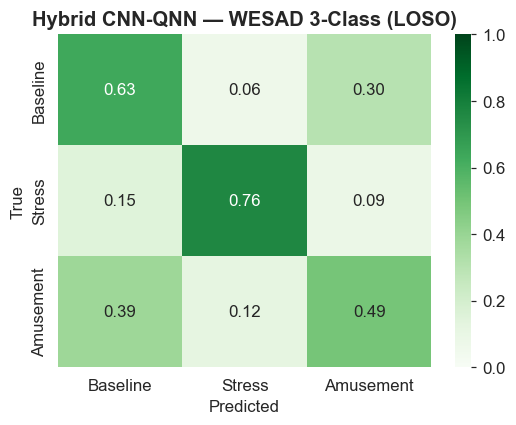

Saved: ..\results\plots\09_hybrid_cnn_qnn\cm_hybrid_wesad_3class.png


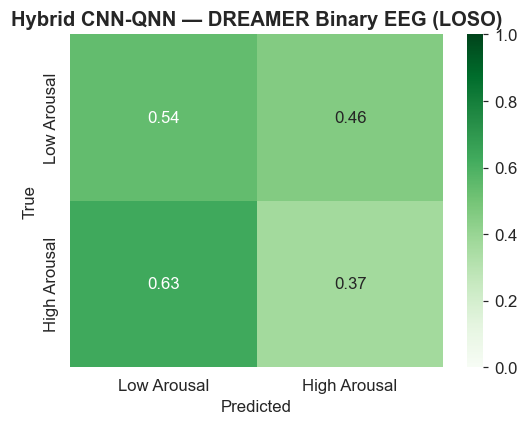

Saved: ..\results\plots\09_hybrid_cnn_qnn\cm_hybrid_dreamer_binary.png


In [32]:
# Confusion matrices
def plot_cm(cm, class_names, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1, annot_kws={'size':11})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_cm(cm_wb, ['Baseline','Stress'],
        'Hybrid CNN-QNN — WESAD Binary (LOSO)',
        os.path.join(PLOTS_DIR, 'cm_hybrid_wesad_binary.png'))
plot_cm(cm_w3, ['Baseline','Stress','Amusement'],
        'Hybrid CNN-QNN — WESAD 3-Class (LOSO)',
        os.path.join(PLOTS_DIR, 'cm_hybrid_wesad_3class.png'))
plot_cm(cm_db, ['Low Arousal','High Arousal'],
        'Hybrid CNN-QNN — DREAMER Binary EEG (LOSO)',
        os.path.join(PLOTS_DIR, 'cm_hybrid_dreamer_binary.png'))


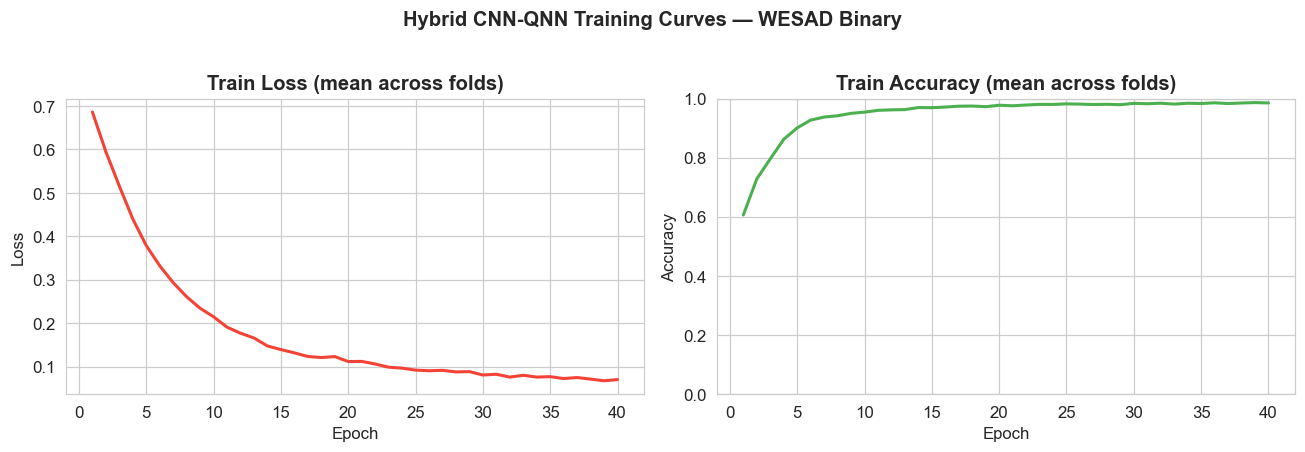

Saved: ..\results\plots\09_hybrid_cnn_qnn\curves_hybrid_wesad_binary.png


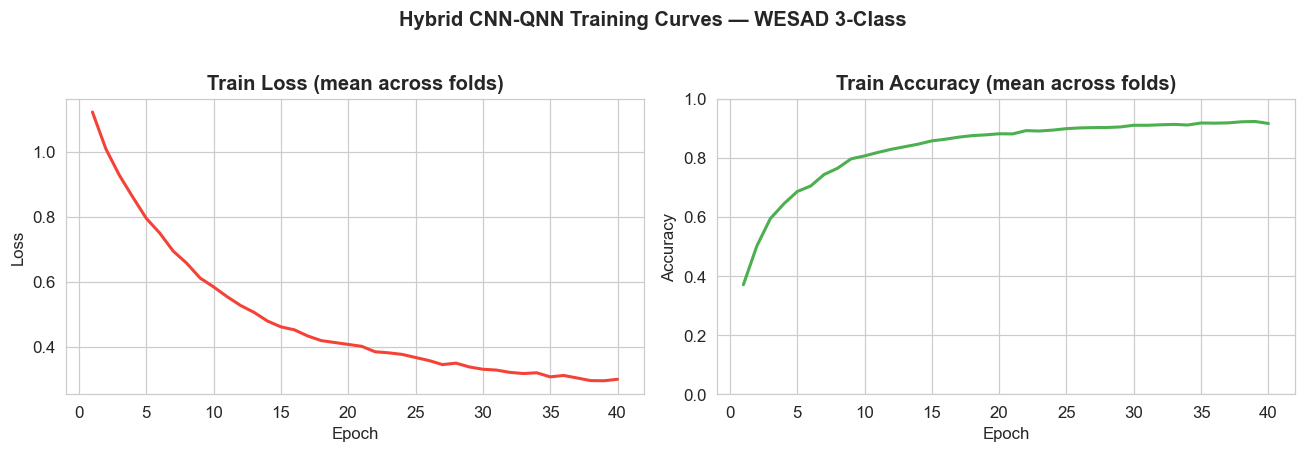

Saved: ..\results\plots\09_hybrid_cnn_qnn\curves_hybrid_wesad_3class.png


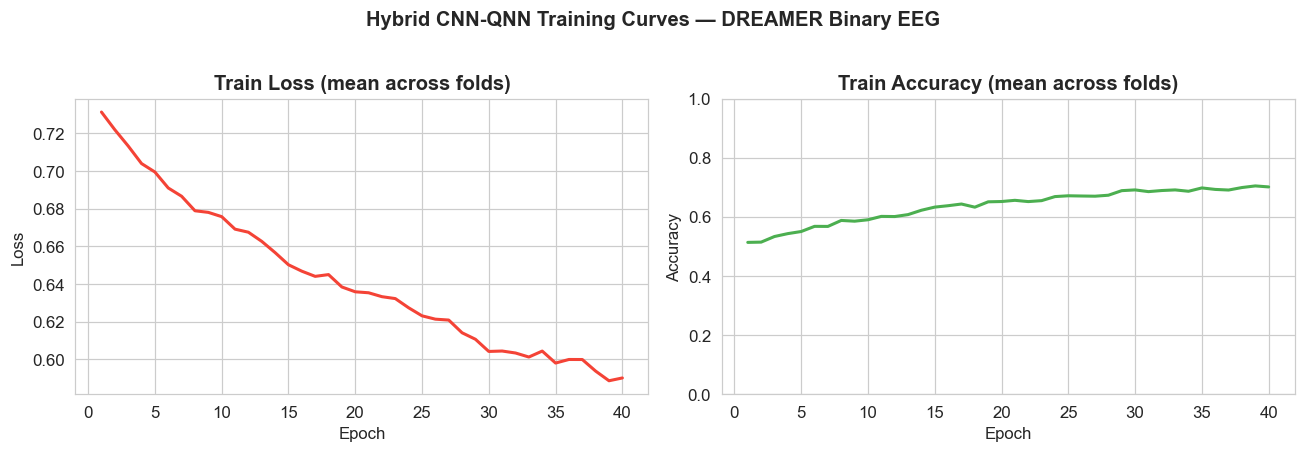

Saved: ..\results\plots\09_hybrid_cnn_qnn\curves_hybrid_dreamer.png


In [33]:
# Training curves — mean across folds
for curves, task_label, fname in [
        (curves_wb, 'WESAD Binary',       'curves_hybrid_wesad_binary.png'),
        (curves_w3, 'WESAD 3-Class',      'curves_hybrid_wesad_3class.png'),
        (curves_db, 'DREAMER Binary EEG', 'curves_hybrid_dreamer.png')]:

    mean_c = curves.groupby('epoch')[['train_loss','train_acc']].mean()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(mean_c.index, mean_c['train_loss'], color='#F44336', lw=2)
    axes[0].set_title('Train Loss (mean across folds)', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[1].plot(mean_c.index, mean_c['train_acc'], color='#4CAF50', lw=2)
    axes[1].set_title('Train Accuracy (mean across folds)', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    plt.suptitle(f'Hybrid CNN-QNN Training Curves — {task_label}',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, fname)
    plt.savefig(p, bbox_inches='tight'); plt.show()
    print(f'Saved: {p}')


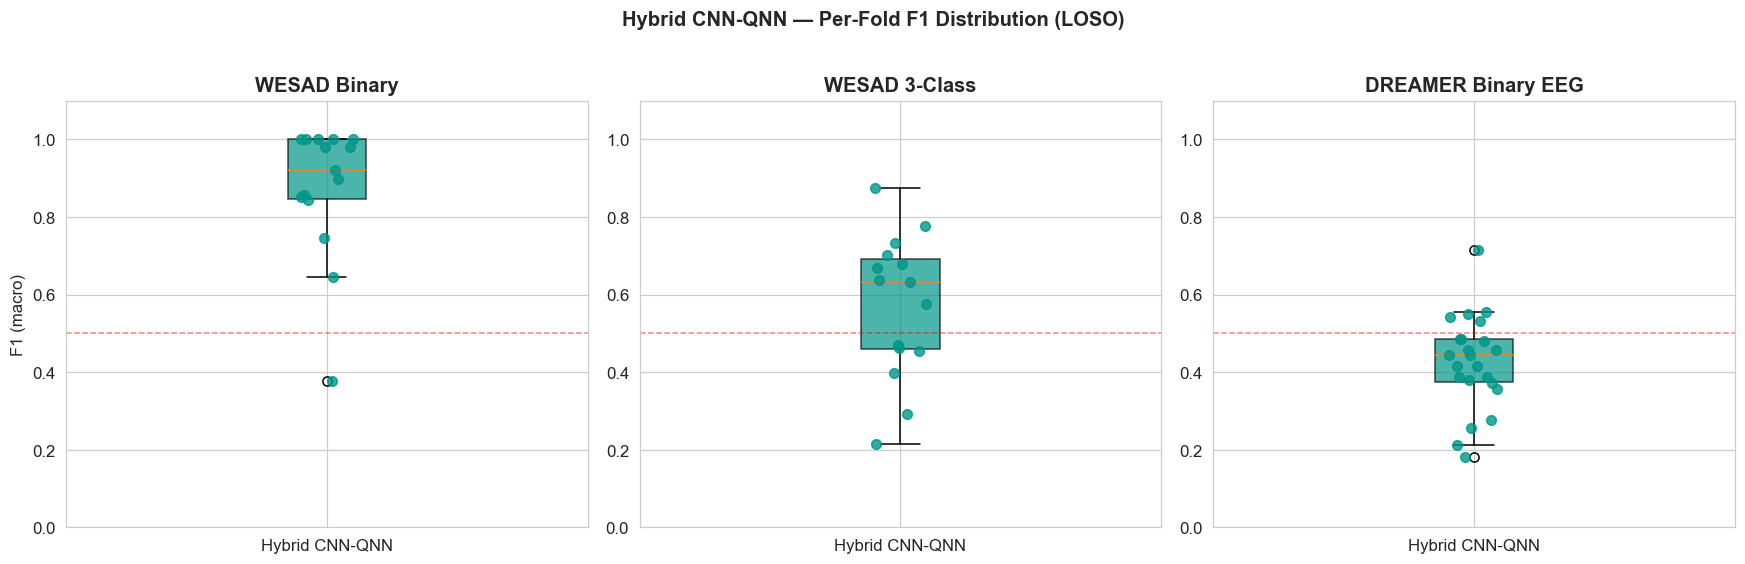

Saved: ..\results\plots\09_hybrid_cnn_qnn\hybrid_f1_per_fold_boxplot.png


In [34]:
# Per-fold F1 boxplot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
task_pairs = [
    ('WESAD_binary_Hybrid',      'WESAD Binary'),
    ('WESAD_3class_Hybrid',      'WESAD 3-Class'),
    ('DREAMER_binary_EEG_Hybrid','DREAMER Binary EEG'),
]
for ax, (task_key, task_label) in zip(axes, task_pairs):
    td = all_hybrid[all_hybrid['task']==task_key]['f1'].values
    ax.boxplot([td], patch_artist=True, labels=['Hybrid CNN-QNN'],
               boxprops=dict(facecolor='#009688', alpha=0.7))
    ax.scatter(np.ones(len(td)) + np.random.uniform(-0.05,0.05,len(td)),
               td, color='#009688', alpha=0.8, zorder=3, s=40)
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)' if ax==axes[0] else '')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.5)
plt.suptitle('Hybrid CNN-QNN — Per-Fold F1 Distribution (LOSO)',
             fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'hybrid_f1_per_fold_boxplot.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


In [35]:
# Stress/Amusement overlap
print('=== Hybrid CNN-QNN: Stress/Amusement Confusion (WESAD 3-class) ===')
cm = cm_w3
total_stress = cm[1,:].sum()
total_amuse  = cm[2,:].sum()
s_a = cm[1,2] / total_stress if total_stress > 0 else 0
a_s = cm[2,1] / total_amuse  if total_amuse  > 0 else 0
print(f'  Stress -> Amusement : {cm[1,2]}/{total_stress} ({s_a*100:.1f}%)')
print(f'  Amusement -> Stress : {cm[2,1]}/{total_amuse}  ({a_s*100:.1f}%)')

hybrid_overlap = pd.DataFrame([{
    'model'                  : 'Hybrid CNN-QNN',
    'stress->amusement_rate' : round(s_a, 4),
    'amusement->stress_rate' : round(a_s, 4),
}])
overlap_path = os.path.join(OUTPUT_DATA_DIR, 'overlap_all_models.csv')
if os.path.exists(overlap_path):
    combined = pd.concat([pd.read_csv(overlap_path), hybrid_overlap],
                          ignore_index=True)
else:
    combined = hybrid_overlap
p = os.path.join(OUTPUT_DATA_DIR, 'overlap_all_models.csv')
combined.to_csv(p, index=False)
print('\n=== Full Overlap Table (all models so far) ===')
print(combined.to_string(index=False))
print(f'\nSaved: {p}')


=== Hybrid CNN-QNN: Stress/Amusement Confusion (WESAD 3-class) ===
  Stress -> Amusement : 27/313 (8.6%)
  Amusement -> Stress : 20/166  (12.0%)

=== Full Overlap Table (all models so far) ===
                                                    model  stress->amusement_rate  amusement->stress_rate
                                      Logistic Regression                  0.1150                  0.0482
                                                SVM (RBF)                  0.1246                  0.0602
                                            Random Forest                  0.0511                  0.1145
QSVM (ZZFeatureMap | n_qubits=3 | reps=2 | full | robust)                  0.2684                  0.2229
    VQC (RealAmplitudes | n_qubits=3 | reps=1 | circular)                  0.0000                  0.5000
                                           Hybrid CNN-QNN                  0.0863                  0.1205

Saved: ..\results\output_data\overlap_all_models.csv


## 10. Summary Log

In [36]:
summary_dict = {
    'notebook'      : '09_hybrid_cnn_qnn',
    'timestamp'     : datetime.now().isoformat(),
    'architecture'  : {
        'classical_front': 'Linear(n_feat->64)+ReLU+Dropout | Linear(64->16)+ReLU | Linear(16->n_qubits)+Tanh',
        'quantum_layer'  : f'PQC: {N_LAYERS} variational layers, {N_QUBITS} qubits, circular CNOT entanglement',
        'classical_out'  : 'Linear(n_qubits->n_classes)',
        'diff_method'    : 'parameter-shift (PennyLane)',
        'optimizer'      : f'Adam(lr={LR}) end-to-end',
    },
    'training'      : {
        'epochs'    : EPOCHS,
        'batch_size': BATCH_SIZE,
        'data'      : 'Full dataset (no subsampling)',
        'scaler'    : 'RobustScaler',
        'sampler'   : 'WeightedRandomSampler (class imbalance)',
    },
    'evaluation'    : 'LOSO',
    'results'       : {}
}

for _, row in summary_hybrid.iterrows():
    summary_dict['results'][row['task']] = {
        'f1_mean'      : row['f1_mean'],
        'f1_std'       : row['f1_std'],
        'accuracy_mean': row['accuracy_mean'],
        'train_time_s' : row['train_time_mean'],
    }

summary_dict['next'] = '10_cross_dataset.ipynb'

p = os.path.join(LOGS_DIR, '09_hybrid_cnn_qnn_summary.json')
with open(p,'w') as f: json.dump(summary_dict, f, indent=2)

print('=' * 60)
print('HYBRID CNN-QNN COMPLETE')
print('=' * 60)
print(json.dumps(summary_dict, indent=2))
print(f'\nLog saved: {p}')


HYBRID CNN-QNN COMPLETE
{
  "notebook": "09_hybrid_cnn_qnn",
  "timestamp": "2026-05-11T13:21:54.595320",
  "architecture": {
    "classical_front": "Linear(n_feat->64)+ReLU+Dropout | Linear(64->16)+ReLU | Linear(16->n_qubits)+Tanh",
    "quantum_layer": "PQC: 2 variational layers, 4 qubits, circular CNOT entanglement",
    "classical_out": "Linear(n_qubits->n_classes)",
    "diff_method": "parameter-shift (PennyLane)",
    "optimizer": "Adam(lr=0.001) end-to-end"
  },
  "training": {
    "epochs": 40,
    "batch_size": 32,
    "data": "Full dataset (no subsampling)",
    "scaler": "RobustScaler",
    "sampler": "WeightedRandomSampler (class imbalance)"
  },
  "evaluation": "LOSO",
  "results": {
    "DREAMER_binary_EEG_Hybrid": {
      "f1_mean": 0.4258,
      "f1_std": 0.1211,
      "accuracy_mean": 0.4662,
      "train_time_s": 8.1813
    },
    "WESAD_3class_Hybrid": {
      "f1_mean": 0.5716,
      "f1_std": 0.185,
      "accuracy_mean": 0.6502,
      "train_time_s": 19.3253
    }